# Exploratory Data Analysis (EDA)

Goal:
- Understand class imbalance
- Analyze feature distributions
- Identify useful features for anomaly detection

In [7]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_data
from src.evaluation.plots import plot_feature_distributions

In [9]:
file_path = "../data/creditcard.csv"

X_train, X_val, X_test, y_train, y_val, y_test = load_data(file_path)

print("Train shape:", X_train.shape)

Train shape: (199364, 10)


In [10]:
class_counts = y_train.value_counts()
class_ratio = y_train.value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass ratio:\n", class_ratio)

Class counts:
 Class
0    199020
1       344
Name: count, dtype: int64

Class ratio:
 Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64


Observation:
- Dataset is highly imbalanced
- Fraud cases are extremely rare
- Accuracy is not a good metric - need PR-AUC, F1

Plot saved to: outputs/figures\eda_feature_distributions.png


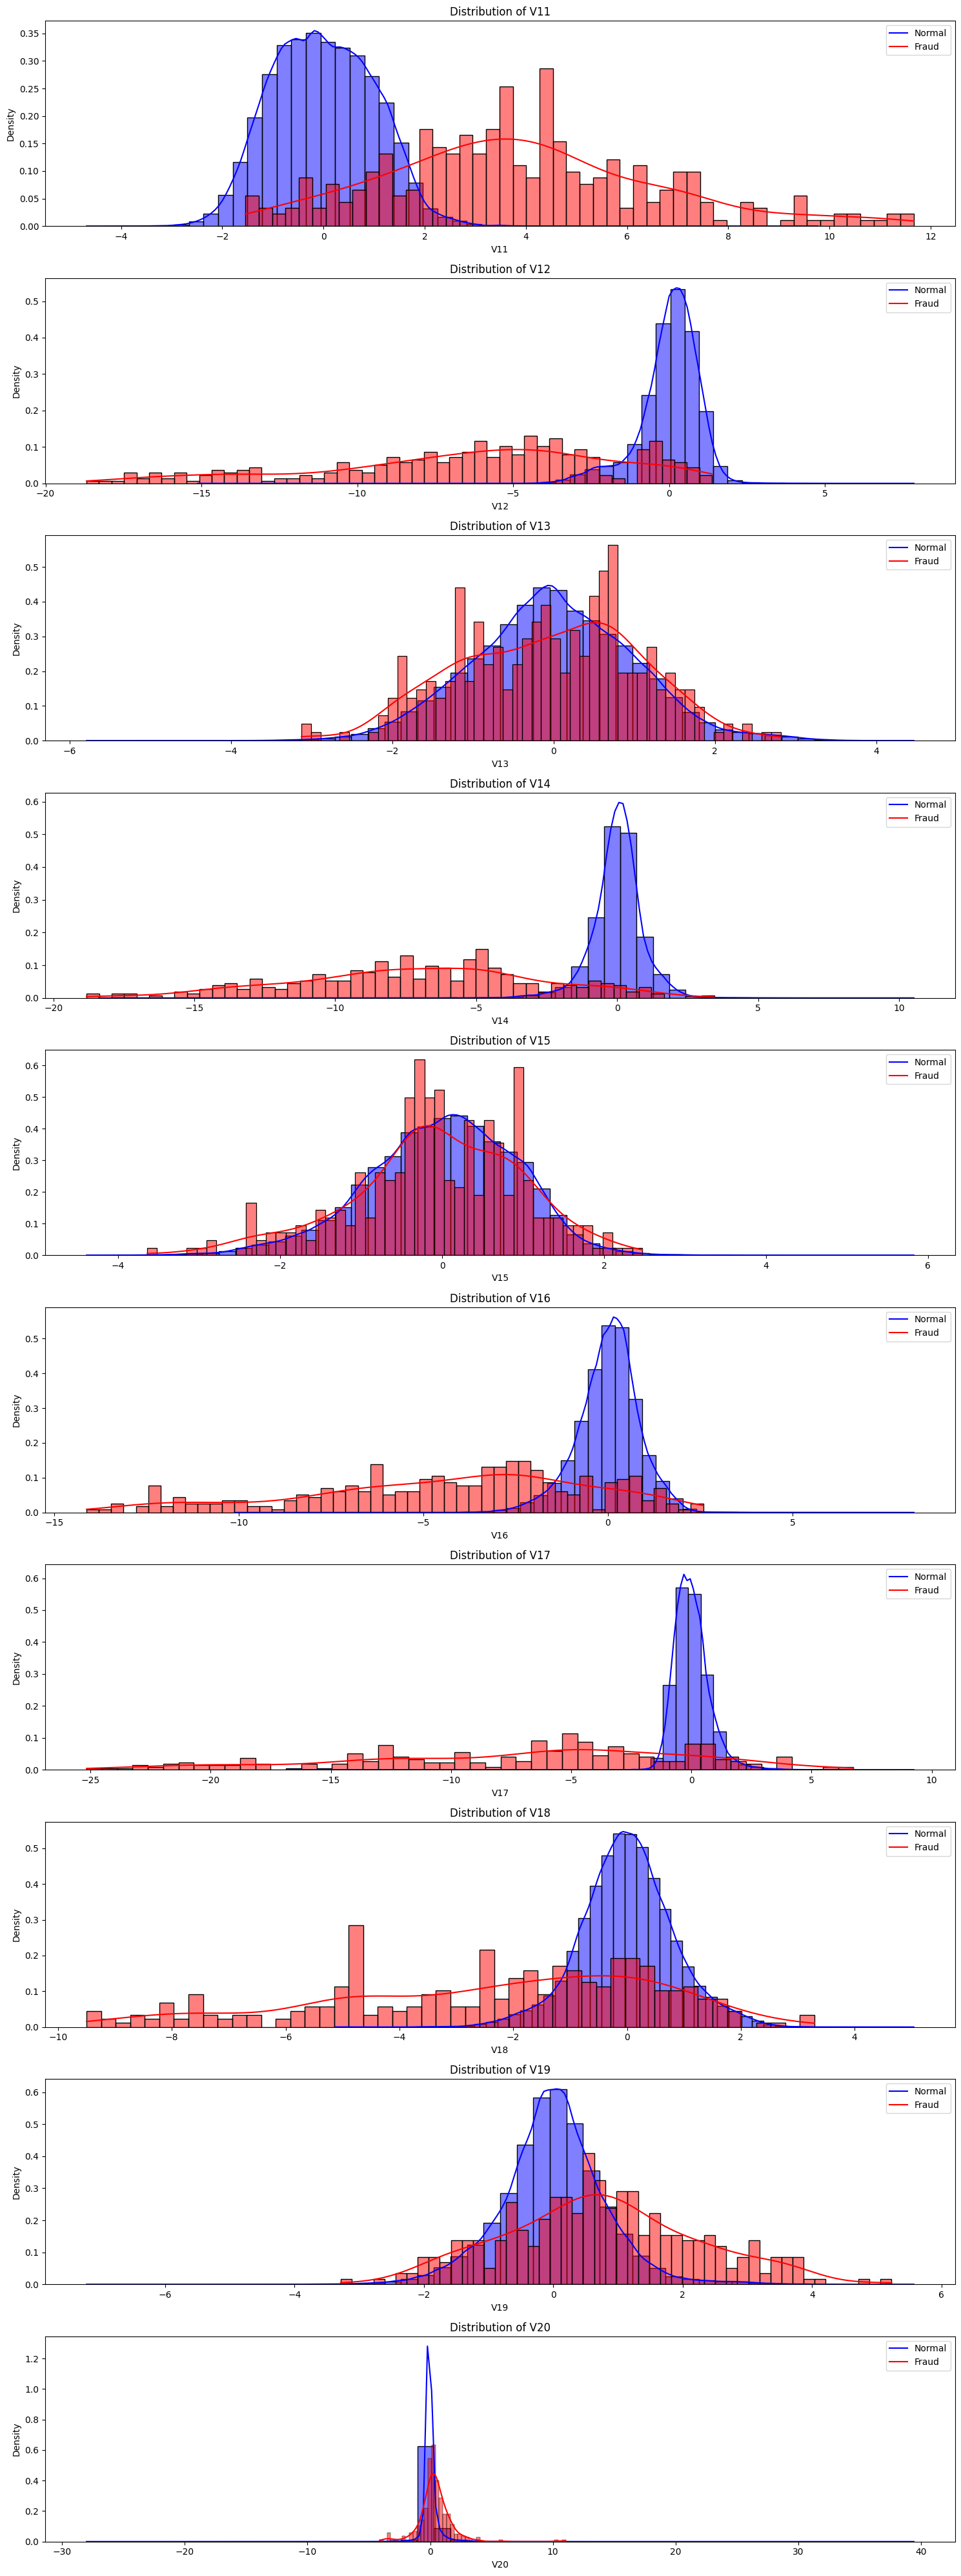

In [11]:
plot_feature_distributions(X_train, y_train, filename="eda_feature_distributions.png")

In these plots, features where the Fraud (blue) and Normal (red) distributions have very different centers or spreads with minimal overlap (such as V11, V12, V14, V16, and V17) are highly valuable input features, as the model can easily use those distinct Gaussian parameters to separate the classes efficiently. In contrast, the features where the normal and fraud distributions heavily overlap (like V13 and V15) indicate that they offer little predictive power for a Gaussian classifier. Features V18 and V19 provide average information for a Gaussian model because their fraud and normal distributions show distinct differences in mean and variance. Conversely, V20 offers almost no predictive power due to the heavy overlap and similarity between its normal and fraudulent transaction distributions. By analyzing these graphs, we can perform feature selection by keeping the most statistically distinct variables to improve the model's accuracy while discarding the unhelpful ones.

Plot saved to: outputs/figures\eda_key_features.png


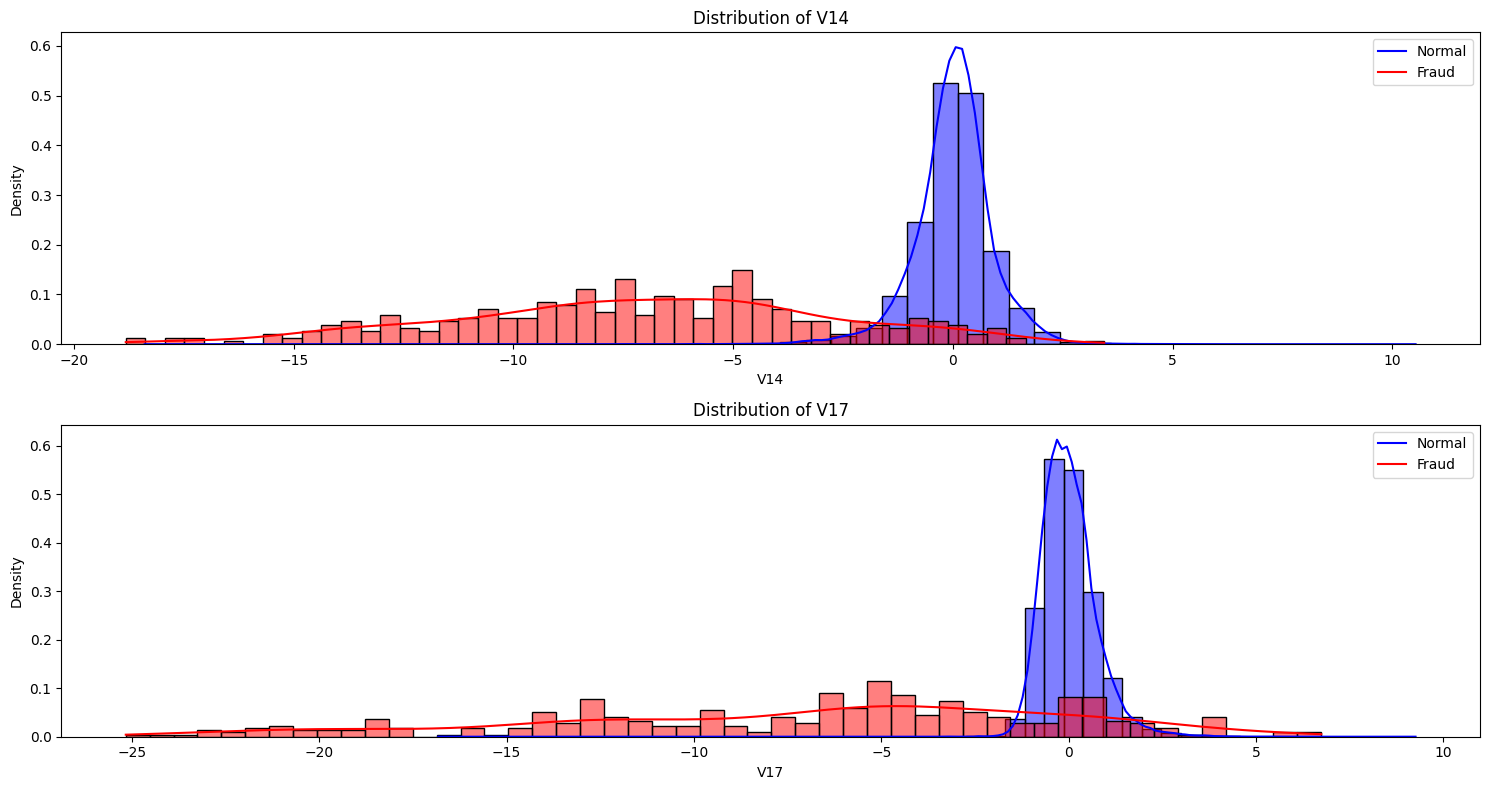

In [12]:
important_features = ["V14", "V17"]

plot_feature_distributions(
    X_train[important_features],
    y_train,
    filename="eda_key_features.png"
)

## Key Insights

- Some features (e.g., V14, V17) show strong separation between fraud and normal transactions
- Fraud cases tend to lie in low-density regions of feature distributions
- This supports using anomaly detection methods like GMM
- Severe class imbalance makes PR-AUC and F1-score more appropriate than accuracy